# Image Classifier - Deep Neural Network

In [1]:
import torch
print(torch.__version__)

2.8.0


In [2]:
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Setting up seed ensures results are reproducible and consistent across runs
torch.manual_seed(25)

#### Device Selection

Select the appropriate device (GPU/MPS for faster training, or CPU if unavailable).

In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## Step 1: Data Preparation

In [4]:
default_data_path = "/Users/akshay/Work/data/"

#### MNIST Dataset

`torchvision.datasets` has a collection of commonly used datasets for vision. **MNIST** is one of the most popular datasets used for classifying handwritten digits.

Loading the dataset from `torchvision.datasets.MNIST`:
- `root` - default folder where files will be saved if not already downloaded
- `train` - setting this to `True`, loads the training partition
- `download` - automatically downloads if the dataset is not present

In [5]:
train_dataset = torchvision.datasets.MNIST(
    root=default_data_path,
    train=True,
    download=True,
)

In [6]:
image_pil, label = train_dataset[0]
print(f"Label: {label}")
print(f"Image size: {image_pil.size}")

Label: 5
Image size: (28, 28)


### Visualizing the Data

Display a sample image from the dataset to understand the data format.

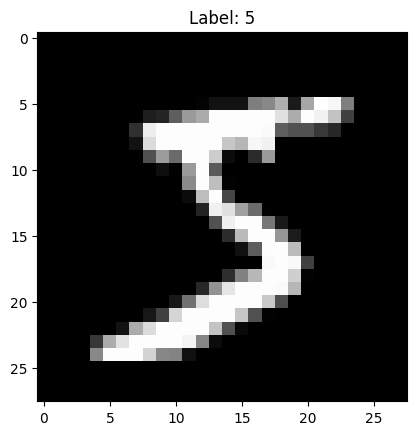

In [7]:
plt.imshow(image_pil, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

### Preparing the Data

#### Defining Transforms

Transforms help in transforming data to the appropriate model input format. `torchvision.transforms` natively supports various types of transformations.

`transforms.Compose()` bundles/chains together a sequence of transformation steps:
- `transforms.ToTensor()` converts images into PyTorch tensors
- `transforms.Normalize()` adjusts the values by centering them around mean and standard deviation

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

Inspect the transformed data - images are now PyTorch tensors with shape [1, 28, 28] (channel, height, width).

Apply transforms to the dataset while loading it again with the `transform` parameter. Create the evaluation/test dataset using the same transforms.


In [9]:
train_dataset = torchvision.datasets.MNIST(
    root=default_data_path,
    train=True,
    transform=transform,
    download=True,
)

In [10]:
image_tensor, label = train_dataset[0]
print(f"Label: {label}")
print(f"Image tensor size: {image_tensor.size()}")
print(f"Image tensor min/max: {image_tensor.min()}/{image_tensor.max()}")

Label: 5
Image tensor size: torch.Size([1, 28, 28])
Image tensor min/max: -0.4242129623889923/2.821486711502075


In [11]:
eval_dataset = torchvision.datasets.MNIST(
    root=default_data_path,
    train=False,
    transform=transform,
    download=True,
)

### Creating the Data Loaders

`DataLoader` batches the data and enables efficient iteration during training. Set `shuffle=True` for training to randomize the order of samples.

In [12]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
)

eval_loader = DataLoader(
    dataset=eval_dataset,
    batch_size=64,
    shuffle=False,
)

## Step 2: Define the Neural Network Model

Defining a custom neural network model by creating a class inheriting from `nn.Module`. As part of `nn.Module`, define two functions:
- `__init__` method: used to define and initialize key components of the model
- `forward` method: used to define the forward pass, the flow of data through the layers

In [13]:
class SimpleDNN(nn.Module):
    """"A simple Deep Neural Network for MNIST classification"""
    def __init__(self):
        super(SimpleDNN, self).__init__()
        """Initialize the model layers"""
        # Define layers
        # Flatten 28x28 images to 784 vector
        self.flatten = nn.Flatten()

        # Sequence of fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)  # 10 output classes for digits 0-9
        )
    
    def forward(self, x):
        """Forward pass of the model"""
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

In [14]:
model = SimpleDNN()
# Move model to the selected device (CPU or GPU)
model.to(device)

SimpleDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

## Step 3: Define Loss Function and Optimizer

- **Loss Function**: Measures the difference between predictions and actual values
- **Optimizer**: Updates model parameters (weights and biases) to minimize the loss
    - **Learning Rate**: Controls how much the optimizer adjusts parameters in each step

In [15]:
loss_fn = nn.CrossEntropyLoss()  # Cross Entropy Loss, most commonly used for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam Optimizer with learning rate 0.001

## Step 4: Training Loop

The training loop repeats the following steps for multiple epochs:
1. Reset gradients: Clear gradients from previous epochs
2. Forward pass: Make predictions
3. Calculate loss: Compare predictions with targets
4. Backward pass: Compute gradients
5. Update parameters: Adjust weights and biases

In [ ]:
def train_model(train_loader, model, optimizer, loss_fn, device):
    """
    Train the Deep neural network model for MNIST Classification.
    
    Returns:
        model: Trained model
        avg_epoch_loss: Average training loss across all batches
        avg_epoch_accuracy: Average training accuracy across all batches
    """
    # make sure model is in training mode
    model.train()
    epoch_loss = 0.0
    epoch_accuracy = 0.0

    # Tracker for batch
    tracking_loss = 0.0
    total_tracking_predictions = 0
    correct_predictions = 0
    total_batches = len(train_loader)


    for b_id, (features, targets) in enumerate(train_loader, start=1):
        features, targets = features.to(device), targets.to(device)

        # Reset gradients to zero (gradients accumulate by default)
        optimizer.zero_grad()

        # Forward pass
        predictions = model(features)
        
        # Calculate loss
        loss = loss_fn(predictions, targets)

        # Backward pass
        loss.backward()

        # Update model parameters using computed gradients
        optimizer.step()

        # Update loss trackers
        batch_loss = loss.item()
        tracking_loss += batch_loss
        epoch_loss += batch_loss

        # Evaluate accuracy for the batch
        _, predicted_labels = torch.max(predictions, 1)
        batch_correct = (predicted_labels == targets).sum().item()
        correct_predictions += batch_correct
        total_tracking_predictions += targets.size(0)
        epoch_accuracy += batch_correct


        # Print progress every 100 batches
        if b_id % 100 == 0:
            avg_loss = tracking_loss / 100
            avg_pred_accuracy = correct_predictions / total_tracking_predictions * 100.0
            print(f'Batch [{b_id}/{total_batches}] | Loss: {avg_loss:.4f} | Accuracy: {avg_pred_accuracy:.2f}%')

            tracking_loss = 0.0
            total_tracking_predictions = 0
            correct_predictions = 0
    
    avg_epoch_loss = epoch_loss / total_batches
    avg_epoch_accuracy = epoch_accuracy / (total_batches * train_loader.batch_size) * 100.0

    return model, avg_epoch_loss, avg_epoch_accuracy

In [17]:
num_epochs = 5
train_losses = []
train_accuracies = []

print("Starting training...")
# Defining the training loop
for epoch in range(1, num_epochs + 1):
    model, train_loss, train_acc = train_model(train_loader, model, optimizer, loss_fn, device=device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc/100.0)
    print("---------------------------------------------------------------------------------------------------")
    print(f'Epoch [{epoch}/{num_epochs}] | Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%')
    print("---------------------------------------------------------------------------------------------------")

Starting training...
Batch [100/938] | Loss: 0.7265 | Accuracy: 80.36%
Batch [200/938] | Loss: 0.3304 | Accuracy: 90.09%
Batch [300/938] | Loss: 0.2654 | Accuracy: 91.70%
Batch [400/938] | Loss: 0.2497 | Accuracy: 92.33%
Batch [500/938] | Loss: 0.2126 | Accuracy: 93.50%
Batch [600/938] | Loss: 0.1907 | Accuracy: 94.23%
Batch [700/938] | Loss: 0.1983 | Accuracy: 94.05%
Batch [800/938] | Loss: 0.1747 | Accuracy: 94.86%
Batch [900/938] | Loss: 0.1708 | Accuracy: 94.83%
---------------------------------------------------------------------------------------------------
Epoch [1/5] | Training Loss: 0.2744 | Accuracy: 91.88%
---------------------------------------------------------------------------------------------------
Batch [100/938] | Loss: 0.1215 | Accuracy: 96.28%
Batch [200/938] | Loss: 0.1270 | Accuracy: 96.17%
Batch [300/938] | Loss: 0.1354 | Accuracy: 95.88%
Batch [400/938] | Loss: 0.1129 | Accuracy: 96.36%
Batch [500/938] | Loss: 0.1213 | Accuracy: 96.41%
Batch [600/938] | Loss: 

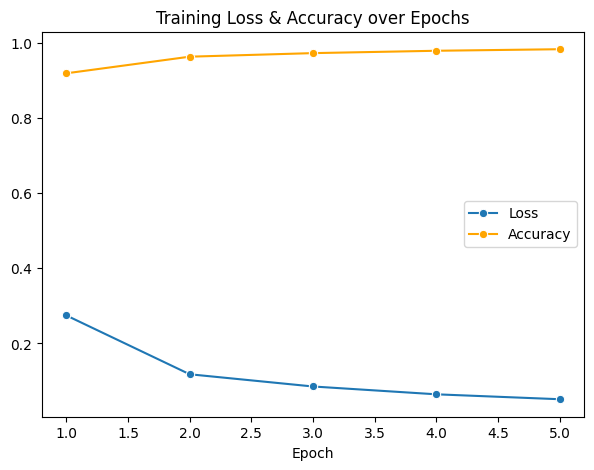

In [ ]:
import seaborn as sns
# Plot training loss over epochs
plt.figure(figsize=(7, 5))
sns.lineplot(x=range(1, num_epochs + 1), y=train_losses, marker='o', label='Loss')
sns.lineplot(x=range(1, num_epochs + 1), y=train_accuracies, marker='o', color='orange', label='Accuracy')
plt.title('Training Loss & Accuracy over Epochs')
plt.legend(loc='center right')  # Position legend at center right
plt.xlabel('Epoch')
plt.show()

## Step 5: Evaluating Model

Use the trained model to predict prices for new house sizes. Use `model.eval()` to set the model for evaluation and `torch.no_grad()` to disable gradient computation during inference (saves memory and computation).

In [ ]:
def evaluate(model, test_loader, device):
    """
    Evaluate the trained model on the test dataset.
    """
    total_correct_predictions = 0
    total_predictions = 0
    # model.eval() set the model to evaluation mode (does not evaluate model)
    model.eval()
    with torch.no_grad(): # Disable gradient calculation/tracking
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            predictions = model(features)

            _, predicted_labels = torch.max(predictions, 1)
            correct_predictions = (predicted_labels == targets).sum().item()
            total_correct_predictions += correct_predictions
            total_predictions += targets.size(0)
        
        accuracy = total_correct_predictions / total_predictions * 100.0
        print(f'Test Accuracy: {accuracy:.2f}%')
        
        return accuracy

In [20]:
model_accuracy = evaluate(model, eval_loader, device)

Test Accuracy: 97.59%
